In [4]:
import os
import pandas as pd

INCLUDE_PATH = os.path.join("..", "dataset", "raw", "include")

summary = []

for part in sorted(os.listdir(INCLUDE_PATH)):
    part_path = os.path.join(INCLUDE_PATH, part)

    if os.path.isdir(part_path):
        for category in os.listdir(part_path):
            category_path = os.path.join(part_path, category)

            if os.path.isdir(category_path):
                signs = [
                    s for s in os.listdir(category_path)
                    if os.path.isdir(os.path.join(category_path, s))
                ]

                summary.append({
                    "Part": part,
                    "Category": category,
                    "Signs": len(signs)
                })

summary_df = pd.DataFrame(summary)

print("Total category parts:", len(summary_df))
summary_df.head(10)

Total category parts: 44


,Part,Category,Signs
0,Adjectives_1of8,Adjectives,8
1,Adjectives_2of8,Adjectives,14
2,Adjectives_3of8,Adjectives,13
3,Adjectives_4of8,Adjectives,6
4,Adjectives_5of8,Adjectives,5
5,Adjectives_6of8,Adjectives,5
6,Adjectives_7of8,Adjectives,5
7,Adjectives_8of8,Adjectives,3
8,Animals_1of2,Animals,5
9,Animals_2of2,Animals,3


In [5]:
# Combine split parts into one category

category_summary = (
    summary_df.groupby("Category", as_index=False)["Signs"]
    .sum()
    .sort_values("Signs", ascending=False)
)

print("Total Categories:", len(category_summary))
category_summary

Total Categories: 15


,Category,Signs
0,Adjectives,59
7,Home,27
10,People,26
14,Society,23
4,Days_and_Time,21
11,Places,19
8,Jobs,16
3,Colours,11
5,Electronics,10
2,Clothes,10


In [6]:
import os

INCLUDE_PATH = os.path.join("..", "dataset", "raw", "include")

found = False

for part in os.listdir(INCLUDE_PATH):
    part_path = os.path.join(INCLUDE_PATH, part)

    if os.path.isdir(part_path):
        for category in os.listdir(part_path):
            category_path = os.path.join(part_path, category)

            if os.path.isdir(category_path):
                for sign in os.listdir(category_path):
                    sign_path = os.path.join(category_path, sign)

                    if os.path.isdir(sign_path):
                        print("Part     :", part)
                        print("Category :", category)
                        print("Sign     :", sign)
                        print("\nContents:")
                        print(os.listdir(sign_path)[:20])   # first 20 files/folders
                        found = True
                        break
            if found:
                break
    if found:
        break

Part     : Adjectives_1of8
Category : Adjectives
Sign     : 1. loud

Contents:
['MVI_5177.MOV', 'MVI_5178.MOV', 'MVI_5179.MOV', 'MVI_5257.MOV', 'MVI_5258.MOV', 'MVI_5259.MOV', 'MVI_5335.MOV', 'MVI_5336.MOV', 'MVI_5337.MOV', 'MVI_9289.MOV', 'MVI_9290.MOV', 'MVI_9291.MOV', 'MVI_9368.MOV', 'MVI_9369.MOV', 'MVI_9370.MOV', 'MVI_9448.MOV', 'MVI_9449.MOV', 'MVI_9450.MOV', 'MVI_9534.MOV', 'MVI_9535.MOV']


In [7]:
import os
import pandas as pd

INCLUDE_PATH = os.path.join("..", "dataset", "raw", "include")

video_stats = []

for part in os.listdir(INCLUDE_PATH):
    part_path = os.path.join(INCLUDE_PATH, part)

    if os.path.isdir(part_path):
        for category in os.listdir(part_path):
            category_path = os.path.join(part_path, category)

            if os.path.isdir(category_path):
                for sign in os.listdir(category_path):
                    sign_path = os.path.join(category_path, sign)

                    if os.path.isdir(sign_path):
                        videos = [
                            f for f in os.listdir(sign_path)
                            if f.lower().endswith((".mp4", ".avi", ".mov"))
                        ]

                        video_stats.append({
                            "Category": category,
                            "Sign": sign,
                            "Videos": len(videos)
                        })

video_df = pd.DataFrame(video_stats)

print("Total Signs:", len(video_df))
print("Total Videos:", video_df["Videos"].sum())

video_df.head(10)

Total Signs: 262
Total Videos: 4257


,Category,Sign,Videos
0,Adjectives,1. loud,21
1,Adjectives,2. quiet,21
2,Adjectives,3. happy,21
3,Adjectives,4. sad,8
4,Adjectives,5. Beautiful,8
5,Adjectives,6. Ugly,8
6,Adjectives,7. Deaf,8
7,Adjectives,8. Blind,8
8,Adjectives,10. Mean,8
9,Adjectives,11. rich,8


In [8]:
print("Total Categories :", category_summary.shape[0])
print("Total Signs      :", len(video_df))
print("Total Videos     :", video_df["Videos"].sum())

print("\nDataset Statistics:\n")
video_df["Videos"].describe()

Total Categories : 15
Total Signs      : 262
Total Videos     : 4257

Dataset Statistics:



count    262.000000
mean      16.248092
std        4.432064
min        4.000000
25%       14.000000
50%       15.000000
75%       20.000000
max       22.000000
Name: Videos, dtype: float64

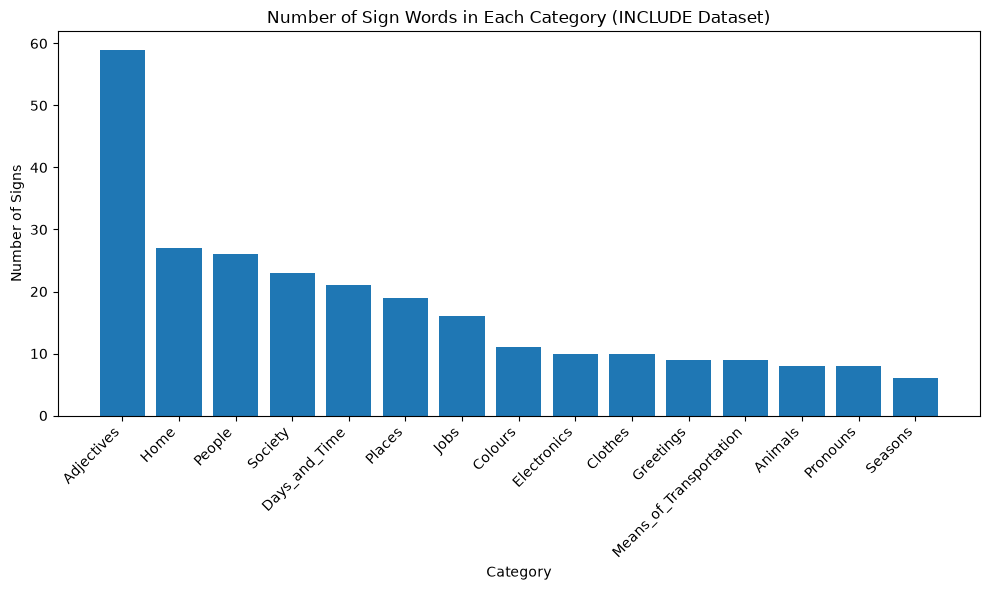

In [11]:
import matplotlib.pyplot as plt  
# Sort by number of signs
plot_df = category_summary.sort_values("Signs", ascending=False)

plt.figure(figsize=(10,6))
plt.bar(plot_df["Category"], plot_df["Signs"])

plt.title("Number of Sign Words in Each Category (INCLUDE Dataset)")
plt.xlabel("Category")
plt.ylabel("Number of Signs")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

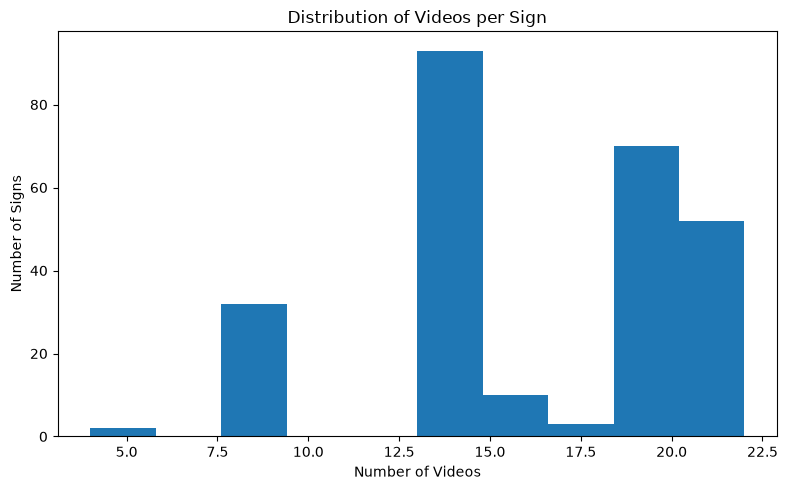

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(video_df["Videos"], bins=10)

plt.title("Distribution of Videos per Sign")
plt.xlabel("Number of Videos")
plt.ylabel("Number of Signs")

plt.tight_layout()
plt.show()